### Universidade Federal do Rio Grande do Sul (UFRGS)   
Programa de Pós-Graduação em Engenharia Civil (PPGEC)   

# PEC00025: Introduction to Vibration Theory


## Test P1 (2026/1): time and frequency domain analysis of sdof systems

---


In [1]:
# Importing Python modules required for this notebook
# (this cell must be executed with "shift+enter" before any other Python cell)

import numpy as np
import matplotlib.pyplot as plt

from MRPy import *


## Dados para a questão 1 (domínio do tempo):

A viga em balanço com massa desprezível sustenta na sua extremidade um guincho com massa $ m = 500 {\rm kg}$ . 
O guincho será usado para erguer uma massa $ M = 2000  {\rm kg} $. O cabo de sustentação é considerado inextensível. 
Dados da viga: $ L = 6  {\rm m} $ , $ EI = 60000{\rm kNm^2} $ . 
A rigidez vertical da extremidade da viga é dada pela fórmula junto à figura. 
O amortecimento é de 1% para qualquer situação.

<img src="resources/tests/PEC00025A_261_P1_Q1.png" alt="PEC00025A_261_P1_Q1" width="540px"/>

Abaixo estão alguns cálculos preliminares de propriedades dinâmicas.

In [2]:
L  =  6.                  # altura da coluna (m)
m  =  500.                # massa a ser içada (kg)
M  =  2000.               # massa da viga + guincho (kg)
zt =  0.01                # amortecimento razão do crítico
EI =  60.0e6              # rigidez à flexão de cada coluna (N.m2)

K  =  3*EI/(L**3)         # rigidez da viga (N/m)

print('Rigidez da viga .....................  K = {0:5.1f} kN/m\n'.format(K/1000))

wM = np.sqrt(K/(M+m))  # frequência natural carga suspensa (rad/s)
fM = wM/(2*np.pi)

print('Frequência natural carga suspensa ... fn = {0:5.2f} Hz'.format(fM))

wn = np.sqrt(K/m)      # frequência natural cabo rompido (rad/s)
fn = wn/(2*np.pi)

print('Frequência natural cabo rompido ..... fn = {0:5.2f} Hz'.format(fn))


Rigidez da viga .....................  K = 833.3 kN/m

Frequência natural carga suspensa ... fn =  2.91 Hz
Frequência natural cabo rompido ..... fn =  6.50 Hz


## Questão (1a):

Considere que o guincho começa a recolher o cabo a uma velocidade $ v_M = 0.5  {\rm m/s} $ . 
Calcule a resposta em vibração livre, $ u(t) $, a partir do momento em que a massa $ M $ deixa o solo. 
Obs.: observe que viga vai se deformar antes disso. (2.5pts)

### _Resolução_

O içamento desloca a extremidade da viga para baixo na velocidade $ v_M $ , 
sem oscilação já que o cabo é inextensível.
Quando a força no cabo iguala o peso da massa $ M $, 
ela tende a decolar do chão, passando a integrar a massa total do sistema. 
Antes da decolagem, apenas a massa $ m $ tem velocidade $ v_M $. 
Após a decolagem as massas $ m + M $ passam a ter velocidade $ v_0 $.
Por conservação de quantidade de movimento (velocidade positiva para baixo):

$$ m v_M = (m + M) v_0 $$

Portanto a velocidade do sistema quando a massa $ M $ decola é igual a:

$$ v_0 = \frac{500{\rm kg} \times 0.5{\rm m/s}}{2500{\rm kg}} = 0.1{\rm m/s}$$

Como é positiva, essa velocidade é também para baixo. 
Por esse cálculo, a massa $ M $ deveria descer com velocidade $ v_0 = 0.1{\rm m/s}$, 
o que a manteria colada ao solo.
No entanto, ela segue sendo içada com $ v_M > v_0 $ e portanto a decolagem
acontece de fato. 

Após a decolagem a força do cabo na extremidade da viga se torna irrelevante,
pois o cabo é inextensível e a massa $ M $ está sendo içada com velocidade constante.
Portanto, tem-se um sistema com massa $ m + M $ em vibração livre com velocidade
inicial $ v_0 $ e deslocamento inicial $ u_0 = Mg/K $, onde $ K $ é a rigidez da viga.

A resposta em vibração livre está calculada abaixo.

In [3]:
g  =  9.81                     # aceleração da gravidade (m/s2)
vM =  0.5                      # velocidade de içamento (m/s)

Fmax =  M*g                    # força máxima (N)
u0   =  Fmax/K                 # deslocamento inicial pós decolagem (m)
t0   =  u0/vM                  # tempo até a decolagem (s)
v0   =  m*vM/(m + M)           # velocidade inicial pós decolagem (m/s)

Td =  1.0                      # tempo total da simulação (s)
fs =  1024.                    # frequência de amostragem (Hz)
N  =  int(Td*fs)               # número de amostras

F  =  MRPy(np.zeros(N), Td=Td)              # após decolagem, massa integrada
u  =  F.sdof_Duhamel(fM, zt, U0=u0, V0=v0)  # resposta dinâmica do sistema m+M
t  =  F.t_axis()

print('Tempo na decolagem ............... t0 = {0:6.4f} s'.format(t0))
print('Deslocamento inicial ............. u0 = {0:6.2f} mm'.format(1000*u0))
print('Velocidade inicial ............... v0 = {0:6.2f} m/s\n'.format(v0))

kmax = np.argmax(u)
tmax = t[kmax]
umax = np.abs(u).max()

print('Tempo no deslocamento máximo ... tmax = {0:6.4f} s'.format(t0+tmax))
print('Deslocamento máximo ............ umax = {0:6.2f} mm'.format(1000*umax))


Tempo na decolagem ............... t0 = 0.0471 s
Deslocamento inicial ............. u0 =  23.54 mm
Velocidade inicial ............... v0 =   0.10 m/s

Tempo no deslocamento máximo ... tmax = 0.0598 s
Deslocamento máximo ............ umax =  24.17 mm


Observa-se que o deslocamento máximo so sistema com massa $ m + M $ é ligeiramente superior ao
deslocamento da extremidade da viga no início da decolagem, justamente porque há uma velocidade inicial.

Abaixo está uma visualização do deslocamento em vibração livre, com o deslocamento máximo marcado em vermelho.

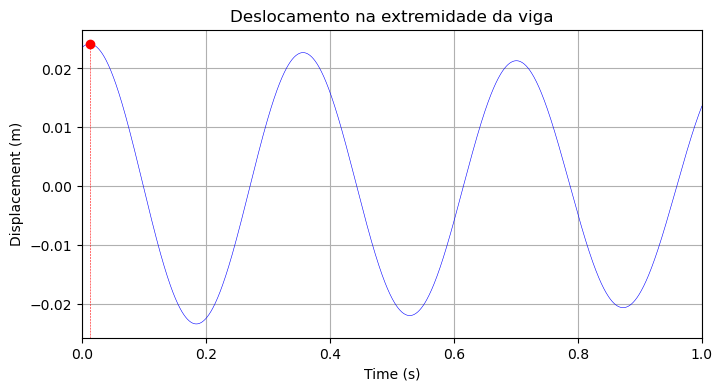

In [4]:
ysup = 1.1*u.max()
yinf = 1.1*u.min()

plt.figure(1, figsize=[8,4], clear=True)

plt.plot(t, u[0],  'b', lw=0.4)
plt.plot(tmax, umax, 'ro')
plt.plot([tmax, tmax], [yinf, umax], 'r--', lw=0.4)

plt.xlabel('Time (s)')
plt.ylabel('Displacement (m)')
plt.axis([0, Td, u.min()*1.1, u.max()*1.1])
plt.grid(True)
plt.title('Deslocamento na extremidade da viga');


Alternativamente, a amplitude máxima pode ser calculada com a expressão:

$$ u_{\rm max} =  \sqrt{u_0^2 + 
                  \left( \frac{v_0 + \zeta \omega_{\rm n} u_0} {\omega_{\rm D}} \right) ^2} $$

onde $u_0$ e $v_0$ são os valores calculados para o instante em que a massa $M$ decola.
Enfatiza-se que, após a decolagem e devido à inextensibilidade do cabo, a massa $M$ passa a se integrar ao sistema,
que então oscila em _vibração livre_.


In [5]:
wD   = wM*np.sqrt(1 - zt**2)   # frequência amortecida (rad/s)

umax = np.sqrt(u0**2 + ((v0 + zt*wM*u0)/wD)**2)

print('Deslocamento máximo ............ umax = {0:5.2f} mm'.format(1000*umax))


Deslocamento máximo ............ umax = 24.23 mm


Observe que este valor é ligeiramente superior ao calculado por integração numérica, já que ele
representa a amplitude do movimento no instante $ t = 0 $, 


## Questão (1b):

uma vez que a massa $M$ deixa o solo, antes de o cabo ser completamente recolhido ele rompe! 
Calcule a resposta, $u(t)$, do sistema viga+guincho em vibração livre amortecida. 
Calcule o máximo momento fletor junto ao engaste da viga em balanço. (2.5pts)

### _Resolução_

A única alteração em relação ao problema anterior é a frequência natural do sistema, 
que agora corresponde apenas à massa $ m $ .


In [6]:
Td =  1.0                      # tempo total da simulação (s)
fs =  1024.                    # frequência de amostragem (Hz)
N  =  int(Td*fs)               # número de amostras

F  =  MRPy(np.zeros(N), Td=Td)              # após decolagem, massa integrada
u  =  F.sdof_Duhamel(fn, zt, U0=u0, V0=v0)  # fn ao invés de fM (!!!)
t  =  F.t_axis()

print('Tempo na decolagem ............... t0 = {0:6.4f} s'.format(t0))
print('Deslocamento inicial ............. u0 = {0:6.2f} mm\n'.format(1000*u0))
print('Velocidade inicial ............... v0 = {0:6.2f} m/s\n'.format(v0))

kmax = np.argmax(u)
tmax = t[kmax]
umax = np.abs(u).max()

print('Tempo no deslocamento máximo ... tmax = {0:6.4f} s'.format(t0+tmax))
print('Deslocamento máximo ............ umax = {0:6.2f} mm'.format(1000*umax))


Tempo na decolagem ............... t0 = 0.0471 s
Deslocamento inicial ............. u0 =  23.54 mm

Velocidade inicial ............... v0 =   0.10 m/s

Tempo no deslocamento máximo ... tmax = 0.0500 s
Deslocamento máximo ............ umax =  23.67 mm


A principal diferença de resultado é que, sendo a frequência bem mais alta, a diferença entre o
deslocamento inicial e o deslocamento máximo é quase insignificante.

Abaixo está uma visualização do deslocamento em vibração livre, com o deslocamento máximo marcado em vermelho.

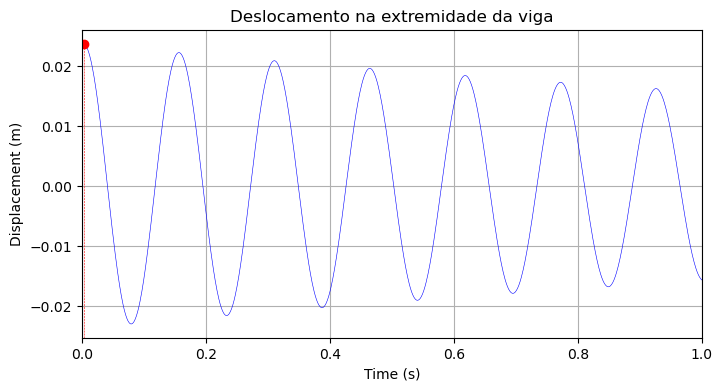

In [7]:
ysup = 1.1*u.max()
yinf = 1.1*u.min()

plt.figure(1, figsize=[8,4], clear=True)

plt.plot(t, u[0],  'b', lw=0.4)
plt.plot(tmax, umax, 'ro')
plt.plot([tmax, tmax], [yinf, umax], 'r--', lw=0.4)

plt.xlabel('Time (s)')
plt.ylabel('Displacement (m)')
plt.axis([0, Td, u.min()*1.1, u.max()*1.1])
plt.grid(True)
plt.title('Deslocamento na extremidade da viga');


Finalmente, abaixo está o mesmo cálculo feito com a expressão da amplitude em vibração livre.

In [8]:
wD   = wn*np.sqrt(1 - zt**2)   # Trocar wM por wn (!!!)

umax = np.sqrt(u0**2 + ((v0 + zt*wn*u0)/wD)**2)

print('Deslocamento máximo ............ umax = {0:5.2f} mm'.format(1000*umax))


Deslocamento máximo ............ umax = 23.70 mm


E novamente o valor da amplitude é ligeiramente superior por se tratar de $ t = 0 $.

## Dados para a questão 2 (domínio da frequência):

o pórtico tem colunas com massa desprezível e viga superior rígida com massa $ m = 10000{\rm kg} $ . Dados para as colunas: $ L = 6  {\rm m} $ , $ EI = 30000{\rm kNm^2} $ (cada). A rigidez horizontal no topo das colunas é dada pela fórmula junto à figura. O amortecimento é de 1% para qualquer situação.

<img src="resources/tests/PEC00025A_261_P1_Q2.png" alt="PEC00025A_261_P1_Q2" width="540px"/>

Abaixo estão alguns cálculos preliminares de propriedades dinâmicas.

In [9]:
L  =  6.                  # altura da coluna (m)
m  =  10000.              # massa a ser içada (kg)
zt =  0.01                # amortecimento razão do crítico
EI =  30.0e6              # rigidez à flexão de cada coluna (N.m2)

K  =  2*12*EI/(L**3)     # rigidez horizontal do pórtico (N/m)

print('Rigidez do pórtico .............  K = {0:5.1f} kN/m'.format(K/1000))

wn = np.sqrt(K/m)         # frequência natural do pórtico (rad/s)
fn = wn/(2*np.pi)

print('Frequência natural do pórtico ... fn = {0:5.2f} Hz'.format(fn))


Rigidez do pórtico .............  K = 3333.3 kN/m
Frequência natural do pórtico ... fn =  2.91 Hz


## Questão (2a):

O pórtico é submetido a um sismo cuja densidade espectral é do tipo "pink noise" em banda, $ k^2/f $ , 
tal como mostrado na figura juntamente com cálculos preliminares para ajustar a variância total 
da aceleração em $ {\rm m/s^2} $ , que resulta $ 9k^2 = 1 {\rm (m/s^2)^2} $ . 
Estime o valor r.m.s. (raiz da variância) e o valor de pico da resposta do pórtico em deslocamento, $ u(t) $ .
Calcule também o momento fletor na base das colunas. (2.5pts)

<img src="resources/tests/PEC00025A_261_P1_Q2_spectrum.png" alt="PEC00025A_261_P1_Q2_spectrum" width="640px"/>

### _Resolução_

Vamos inicialmente construir a densidade espectral da aceleração a partir das especificações fornecidas.

In [10]:
c  =  9.0                # fator de ajuste da banda de frequência
k2 =  1.0/c              # impõe a variância total da aceleração, 9k2 = 1 (m/s^2)^2
b  =  c/(2*np.log(10))

f0 =  10**(-b)
f1 =  10**( b)
f  =  np.logspace(np.log10(f0), np.log10(f1), 100)   # discretização logarítmica

Sa =  k2/f
sa =  np.sqrt(np.trapz(Sa, f))                       # verificaçã do valor r.m.s.

print('Limite inferior da banda de frequência ... f0 = {0:5.3f} Hz'.format(f0))
print('Limite superior da banda de frequência ... f1 = {0:5.2f} Hz'.format(f1))
print('Valor r.m.s. da aceleração ............... sa = {0:5.2f} m/s²'.format(sa))


Limite inferior da banda de frequência ... f0 = 0.011 Hz
Limite superior da banda de frequência ... f1 = 90.02 Hz
Valor r.m.s. da aceleração ............... sa =  1.00 m/s²


Para o cálculo da densidade espectral do deslocamento é feita uma discretização compatível para 
a admitância aerodinâmica.

$$ \lvert H(\omega) \rvert^2 = \frac{1}{\omega_{\rm n}^4} \; \left[ \frac{1}{(1 - \beta^2)^2 + (2\zeta\beta)^2} \right]$$

onde $\beta = \omega/\omega_{\rm n} = f/f_{\rm n}$. 
Neste cálculo, onde a excitação é uma aceleração da base, não é necessário considerar a massa do
sistema pois a expressão acima já está com a massa fatorada.

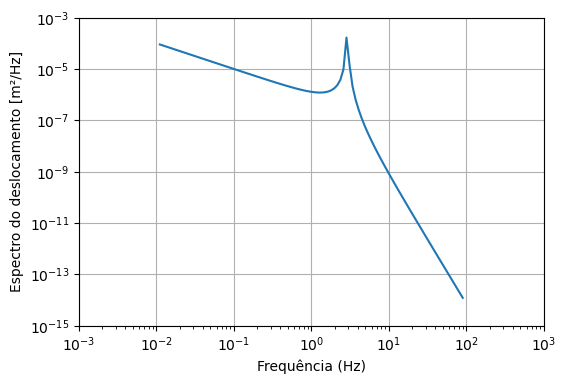

In [11]:
H2  = lambda fi: 1/( (1 - (fi/fn)**2)**2 + (2*zt*(fi/fn))**2 )/(wn**4)
SU  = H2(f)*Sa

plt.figure(3, figsize=(6,4), clear=True)
plt.loglog(f, SU);
plt.grid(True)
plt.axis([1e-3, 1e3, 1e-15, 1e-3])
plt.xlabel('Frequência (Hz)')
plt.ylabel('Espectro do deslocamento [m²/Hz]');


Abaixo está o cálculo do valor r.m.s. do deslocamento obtido pela integral do espectro, 
bem como o respectivo valor de pico calculado pela fórmula de Davenport. 
Como a duração do sismo não é fornecida, admite-se uma duração razoável de 1 minuto (60s).

In [12]:
urms = np.sqrt(np.trapz(SU, f))

T    = 60.      # tempo de observação (1min de sismo)
nu0  = fn       # aproximação, mas geralmente nu0 é menor que fn

lnu = np.sqrt(2*np.log(T*nu0))
gp  = lnu + 0.5772/lnu

upk = gp*urms

print('Valor r.m.s. do deslocamento ........... urms = {0:5.2f} mm'.format(1000*urms))
print('Fator de pico para 60s ................. gpk  = {0:5.2f}'.format(gp))
print('Valor de pico em 60s do deslocamento ... upk  = {0:5.2f} mm'.format(1000*upk))


Valor r.m.s. do deslocamento ........... urms =  7.60 mm
Fator de pico para 60s ................. gpk  =  3.39
Valor de pico em 60s do deslocamento ... upk  = 25.78 mm


## Questão (2b):

Calcule um novo valor para a rigidez das colunas, $EI$, tal que a amplitude máxima da resposta ao sismo caia pela metade do valor calculado em na questão 2a. (2.5pts)

### _Resolução_

Vamos primeiro alterar iterarivamente a frequência natural do pórtico até que o 
deslocamento de pico caia aproximadamente à metade.

In [13]:
wnX   = 1.5672*wn       # fator de alteração da frequência natural (por iteração)
fnX   = wnX/(2*np.pi)

H2X   = lambda fi: 1/( (1 - (fi/fnX)**2)**2 + (2*zt*(fi/fnX))**2 )/(wnX**4)
SUX   = H2X(f)*Sa

urmsX = np.sqrt(np.trapz(SUX, f))

nu0   = fnX
lnu   = np.sqrt(2*np.log(T*nu0))
gp    = lnu + 0.5772/lnu
upk   = gp*urmsX

print('Novo valor de pico do deslocamento ... upk = {0:5.2f} mm'.format(1000*upk))
print('Nova frequencia natural do pórtico .... wn = {0:5.2f} rad/s'.format(wnX))
print('Nova frequencia natural do pórtico .... fn = {0:5.2f} Hz'.format(fnX))


Novo valor de pico do deslocamento ... upk = 12.89 mm
Nova frequencia natural do pórtico .... wn = 28.61 rad/s
Nova frequencia natural do pórtico .... fn =  4.55 Hz


Uma vez conhecida a frequência natural necessária para reduzir o deslocamento de pico,
calcula-se a rigidez $ EI $ correspondente.


In [14]:
KX =  m*(wnX**2)           # nova rigidez do pórtico (N/m)
EI =  KX*(L**3)/(2*12)     # nova rigidez à flexão de cada coluna (N.m2)

print('Nova rigidez do pórtico ................. K = {0:6.1f} kN/m'.format(KX/1000))
print('Nova rigidez à flexão de cada coluna ... EI = {0:6.0f} kN.m²'.format(EI/1e2))


Nova rigidez do pórtico ................. K = 8187.1 kN/m
Nova rigidez à flexão de cada coluna ... EI = 736835 kN.m²


Percebe-se, portanto, que é necessário um aumento de mais de 12 vezes na rigidez à flexão de cada coluna
para cumprir o objetivo de reduzir o pico do deslocamento à metade!
